# Roman Grism Sensitivity Curves

This notebook reads and plots the grism sensitivity curves for different spectral orders.

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

## Load Sensitivity Files

In [2]:
# Define files and labels
sensitivity_files = {
    'Order 1': '../../data/sensitivities/SCA1_sens_12052024.fits',
    'Order 0': '../../data/sensitivities/SCA1_sens_12052024_order0.fits',
    'Order 2': '../../data/sensitivities/SCA1_sens_12052024_order2.fits',
}

# Load data and show headers
sensitivities = {}
for label, fname in sensitivity_files.items():
    with fits.open(fname) as hdul:
        data = hdul[1].data
        header = hdul[1].header
        
        # Convert wavelength from Angstroms to microns
        sensitivities[label] = {
            'wavelength_um': data['WAVELENGTH'] / 1e4,  # Å to μm
            'sensitivity': data['SENSITIVITY'],
            'error': data['ERROR'],
            'header': header,
        }
        print(f"{label}: {len(data)} points, λ = {data['WAVELENGTH'].min()/1e4:.2f} - {data['WAVELENGTH'].max()/1e4:.2f} μm")

Order 1: 2196 points, λ = 0.40 - 2.60 μm
Order 0: 2196 points, λ = 0.40 - 2.60 μm
Order 2: 2196 points, λ = 0.40 - 2.60 μm


## FITS Header Information

Display the header from one of the files to check for unit information.

In [3]:
# Display header from Order 1 file (representative of all files)
print("FITS Header (Order 1 file):")
print("=" * 60)
print(repr(sensitivities['Order 1']['header']))
print()
print("Note: No TUNIT keywords present - units are not specified in the files.")

FITS Header (Order 1 file):
XTENSION= 'BINTABLE'           /Binary table written by MWRFITS v1.6a           
BITPIX  =                    8 /Required value                                  
NAXIS   =                    2 /Required value                                  
NAXIS1  =                   12 /Number of bytes per row                         
NAXIS2  =                 2196 /Number of rows                                  
PCOUNT  =                    0 /Normally 0 (no varying arrays)                  
GCOUNT  =                    1 /Required value                                  
TFIELDS =                    3 /Number of columns in table                      
COMMENT                                                                         
COMMENT  *** End of mandatory fields ***                                        
COMMENT                                                                         
COMMENT                                                                         


## Plot Sensitivity Curves (0.9 - 2.0 μm)

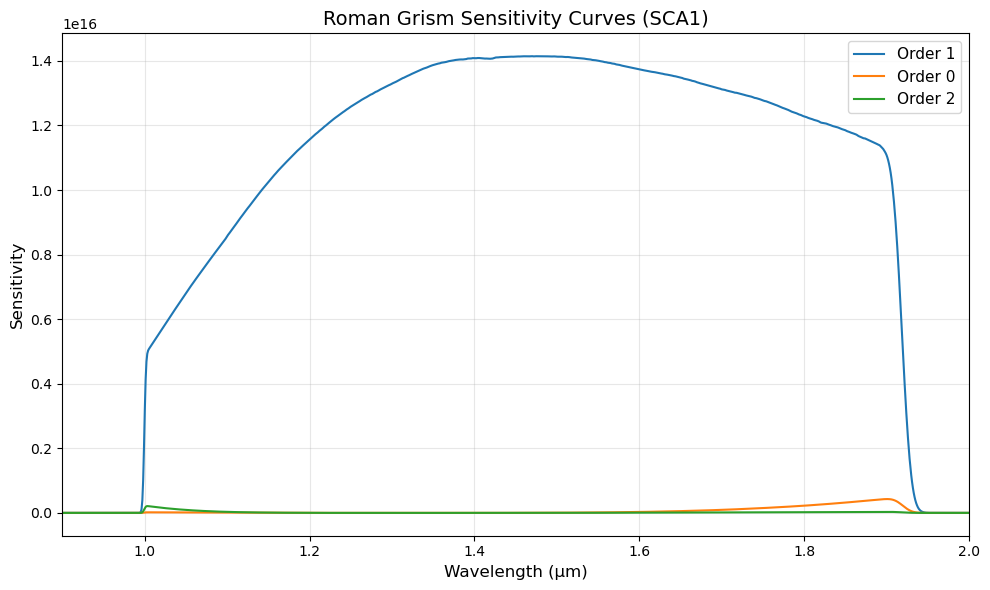

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Order 0': 'C1', 'Order 1': 'C0', 'Order 2': 'C2'}

for label, data in sensitivities.items():
    wl = data['wavelength_um']
    sens = data['sensitivity']
    
    # Filter to 0.9 - 2.0 μm
    mask = (wl >= 0.9) & (wl <= 2.0)
    ax.plot(wl[mask], sens[mask], label=label, color=colors[label], lw=1.5)

ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Sensitivity', fontsize=12)
ax.set_title('Roman Grism Sensitivity Curves (SCA1)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0.9, 2.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Log Scale View

Since the orders span several orders of magnitude, a log scale helps compare their shapes.

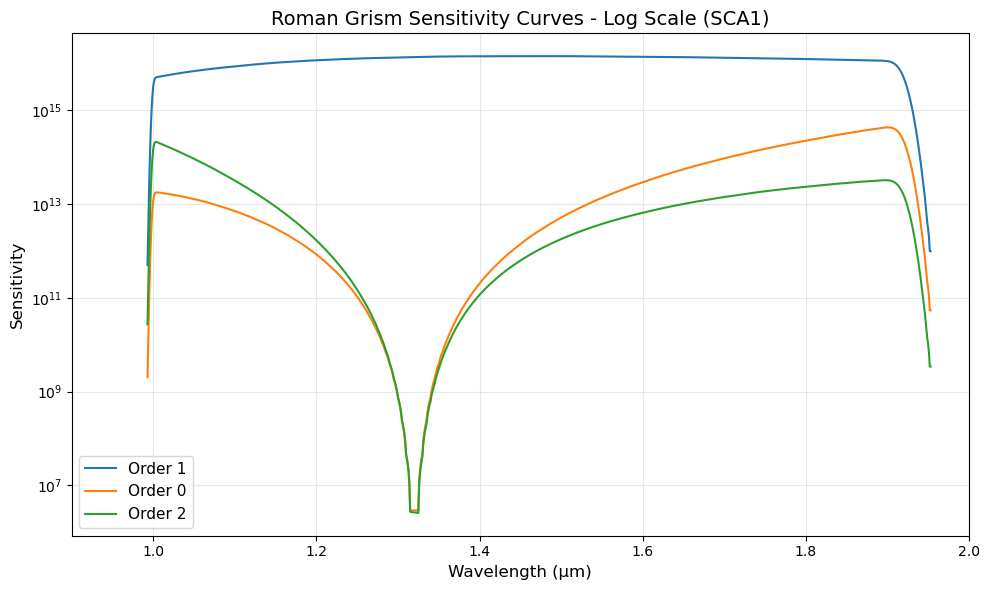

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, data in sensitivities.items():
    wl = data['wavelength_um']
    sens = data['sensitivity']
    
    # Filter to 0.9 - 2.0 μm and positive sensitivity
    mask = (wl >= 0.9) & (wl <= 2.0) & (sens > 0)
    ax.semilogy(wl[mask], sens[mask], label=label, color=colors[label], lw=1.5)

ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Sensitivity', fontsize=12)
ax.set_title('Roman Grism Sensitivity Curves - Log Scale (SCA1)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0.9, 2.0)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Normalized Comparison

Normalize each curve to its peak to compare spectral shapes.

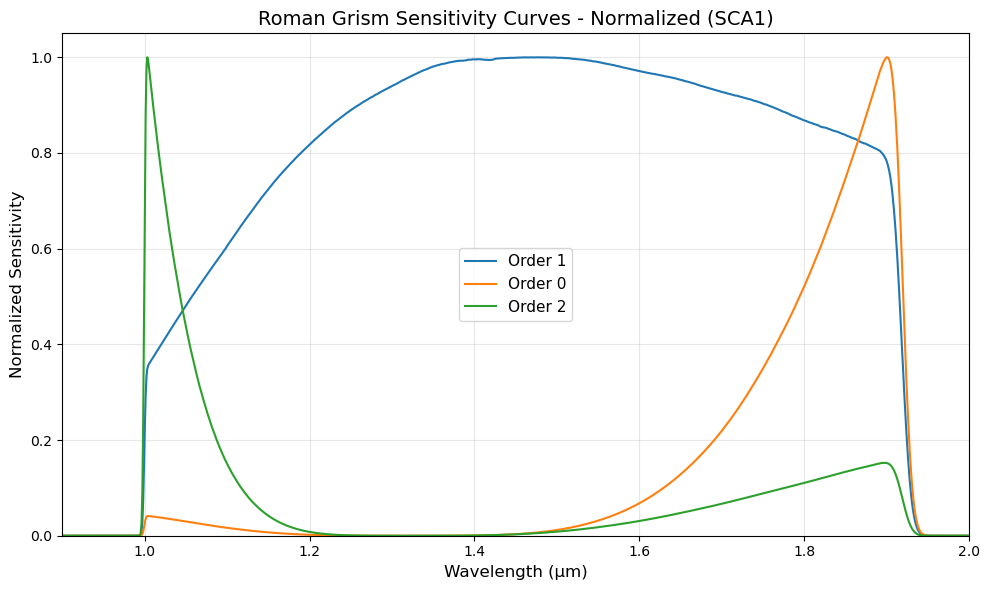

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, data in sensitivities.items():
    wl = data['wavelength_um']
    sens = data['sensitivity']
    
    # Filter to 0.9 - 2.0 μm
    mask = (wl >= 0.9) & (wl <= 2.0)
    wl_filt = wl[mask]
    sens_filt = sens[mask]
    
    # Normalize to peak
    sens_norm = sens_filt / sens_filt.max()
    ax.plot(wl_filt, sens_norm, label=label, color=colors[label], lw=1.5)

ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Normalized Sensitivity', fontsize=12)
ax.set_title('Roman Grism Sensitivity Curves - Normalized (SCA1)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0.9, 2.0)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

In [7]:
print("Peak sensitivities in 0.9-2.0 μm range:")
print("-" * 50)

for label, data in sensitivities.items():
    wl = data['wavelength_um']
    sens = data['sensitivity']
    
    mask = (wl >= 0.9) & (wl <= 2.0)
    wl_filt = wl[mask]
    sens_filt = sens[mask]
    
    peak_idx = np.argmax(sens_filt)
    peak_wl = wl_filt[peak_idx]
    peak_sens = sens_filt[peak_idx]
    
    print(f"{label}: peak = {peak_sens:.3e} at λ = {peak_wl:.3f} μm")

Peak sensitivities in 0.9-2.0 μm range:
--------------------------------------------------
Order 1: peak = 1.415e+16 at λ = 1.482 μm
Order 0: peak = 4.283e+14 at λ = 1.901 μm
Order 2: peak = 2.104e+14 at λ = 1.003 μm
